Testing Bijection

Function definitions

In [ ]:
from itertools import combinations

# Generates a list of all subgraphs of a graph G
def all_subgraphs(G):
    edges = G.edges(labels=False)
    V = G.vertices()
    subgraphs = []

    for k in range(len(edges) + 1):
        for E in combinations(edges, k):
            H = Graph()
            H.add_vertices(V)
            H.add_edges(E)
            subgraphs.append(H)

    return subgraphs

# Generates a list representing the degree sequence of G
def get_sequence(G):
    return [G.degree(v) for v in G.vertices()]

# Generates a nested list the edges of cycles of G
def make_cycles(G):
    cycles = G.all_simple_cycles()
    cycs = []
    for c in cycles:
        c_edges = []
        for i in range(len(c) - 1):
            c_edges.append((c[i], c[i + 1]))
        cycs.append(c_edges)
    return cycs

# Generates a list of all subgraphs of G containing alternating cycles
def find_alt_cycles(G):
    alt_cycles = []
    subs = all_subgraphs(G)
    cyc = make_cycles(G)
    for s in subs:
        e = {tuple(sorted(edge)) for edge in s.edges(labels=False)}
        for c in cyc:
            c = [tuple(sorted(edge)) for edge in c]
            c1 = c[::2]
            c2 = c[1::2]
            if (all(edge in e for edge in c1)) and (all(edge not in e for edge in c2)):
                alt_cycles.append(s)
                break
            elif (all(edge in e for edge in c2)) and (all(edge not in e for edge in c1)):
                alt_cycles.append(s)
                break

    return alt_cycles

Setting up graphs for testing bijection on bipartite graph on 6 vertices

In [ ]:
# Setting up test graph
partition = [[1, 4, 5], [2, 3, 6]]
color_dict = {'red': partition[0], 'blue': partition[1]}
G = BipartiteGraph({1: [2, 3], 4: [2, 3, 6], 5:[3, 6]}, partition)

# Labeling edges
G.set_edge_label(1, 2, '1')
G.set_edge_label(1, 3, '2')
G.set_edge_label(2, 4, '3')
G.set_edge_label(3, 4, '4')
G.set_edge_label(4, 6, '5')
G.set_edge_label(6, 5, '6')
G.set_edge_label(3, 5, '7')

# Create graphs G3 - G6
G6 = BipartiteGraph({1: [2, 3], 4: [2, 3, 6], 5:[6]}, partition)
G5 = BipartiteGraph({1: [2, 3], 4: [2, 3, 6], 5:[]}, partition)
G4 = BipartiteGraph({1: [2, 3], 4: [2, 3], 5:[], 6:[]}, partition)
G3 = BipartiteGraph({1: [2, 3], 4: [2], 5:[], 6:[]}, partition)

In [ ]:
# Making G3 bijection (identity map)

subs_3 = all_subgraphs(G3)

domain_3 = []

for sub in subs_3:
    if sub.is_forest():
        domain_3.append(sub)

codomain_3 = domain_3.copy()

# Testing for G4

# Generate list of subgraphs
subs_4 = all_subgraphs(G4)
# Generate list of subgraphs with alternating cycles
alt_cycs_4 = find_alt_cycles(G4)
# Generate cycles as lists of edges (tuples)
cycles_4 = make_cycles(G4)

# Identify new edge between G3 and G4
new_edge = (3, 4)

# Create domain for G4 (all subforests of G4)
domain_4 = []

for sub in subs_4:
    if sub.is_forest():
        domain_4.append(sub)

# Create codomain for G4 (copy of codomain of G3 to be added to)
codomain_4 = codomain_3.copy()

# Identify subforests including new edge
new_maps = []

for s in domain_4:
    if s not in domain_3:
        new_maps.append(s)

# Add mapping to codomain based on theory of bijection
for h in new_maps:
    h_prime = h.copy()
    # Delete new edge from h
    h_prime.delete_edge(new_edge)
    # Test if h contains an alternating cycle
    if h_prime in alt_cycs_4:
        # If yes, find for which cycle it alternates, and complete cycle
        # make a function
        e = {tuple(sorted(edge)) for edge in h_prime.edges(labels=False)}
        for cyc in cycles_4:
            # add check: if cycle contains new edge then continue otherwise move on to next cycle
            c = [tuple(sorted(edge)) for edge in cyc]
            c1 = c[::2]
            c2 = c[1::2]
            if ((all(edge in e for edge in c1)) and (all(edge not in e for edge in c2))) or ((all(edge in e for edge in c2)) and (all(edge not in e for edge in c1))):
                h_prime.add_edges(c)
        codomain_4.append(h_prime)
    else:
        # If no, map to itself (before deleting new edge)
        codomain_4.append(h)

print("The number of subforests (domain): {}".format(len(domain_4)))
print("The size of the codomain mapping forests to subgraphs using bijection: {}".format(len(codomain_4)))

ds_4 = set()

for graph in codomain_4:
    ds_4.add(tuple(get_sequence(graph)))

print("The number of distinct degree sequences of subgraphs in the codomain: {}".format(len(ds_4)))

The number of subforests (domain): 15
The size of the codomain mapping forests to subgraphs using bijection: 15
The number of distinct degree sequences of subgraphs in the codomain: 14


Edited code from 4/16

In [ ]:
# Making G3 bijection (identity map)

f = {}

subs_3 = all_subgraphs(G3)

# function sage graph object to 0-1 tuple

def to_tuple(G):
    list_edges = []
    for i in range(1, len(G.edges()) + 1):
        if "{i}" in G.edges():

# also a function that turns a tuple into a graph object



domain_3 = []

for sub in subs_3:
    if sub.is_forest():
        domain_3.append(sub)

codomain_3 = domain_3.copy()

# Testing for G4

# Generate list of subgraphs
subs_4 = all_subgraphs(G4)
# Generate list of subgraphs with alternating cycles
alt_cycs_4 = find_alt_cycles(G4)
# Generate cycles as lists of edges (tuples)
cycles_4 = make_cycles(G4)

# Identify new edge between G3 and G4
new_edge = (3, 4)

# Create domain for G4 (all subforests of G4)
domain_4 = []

for sub in subs_4:
    if sub.is_forest():
        domain_4.append(sub)

# Create codomain for G4 (copy of codomain of G3 to be added to)
codomain_4 = codomain_3.copy()

# Identify subforests including new edge
new_maps = []

for s in domain_4:
    if s not in domain_3:
        new_maps.append(s)

# Add mapping to codomain based on theory of bijection
for h in new_maps:
    h_prime = h.copy()
    # Delete new edge from h
    h_prime.delete_edge(new_edge)
    # Test if h contains an alternating cycle
    if h_prime in alt_cycs_4:
        # If yes, find for which cycle it alternates, and complete cycle
        e = {tuple(sorted(edge)) for edge in h_prime.edges(labels=False)}
        for cyc in cycles_4:
            c = [tuple(sorted(edge)) for edge in cyc]
            c1 = c[::2]
            c2 = c[1::2]
            if ((all(edge in e for edge in c1)) and (all(edge not in e for edge in c2))) or ((all(edge in e for edge in c2)) and (all(edge not in e for edge in c1))):
                h_prime.add_edges(c)
        codomain_4.append(h_prime)
    else:
        # If no, map to itself (before deleting new edge)
        codomain_4.append(h)

print("The number of subforests (domain): {}".format(len(domain_4)))
print("The size of the codomain mapping forests to subgraphs using bijection: {}".format(len(codomain_4)))

ds_4 = set()

for graph in codomain_4:
    ds_4.add(tuple(get_sequence(graph)))

print("The number of distinct degree sequences of subgraphs in the codomain: {}".format(len(ds_4)))

IndentationError: expected an indented block after 'if' statement on line 12 (587152847.py, line 18)

Visualizing the domain

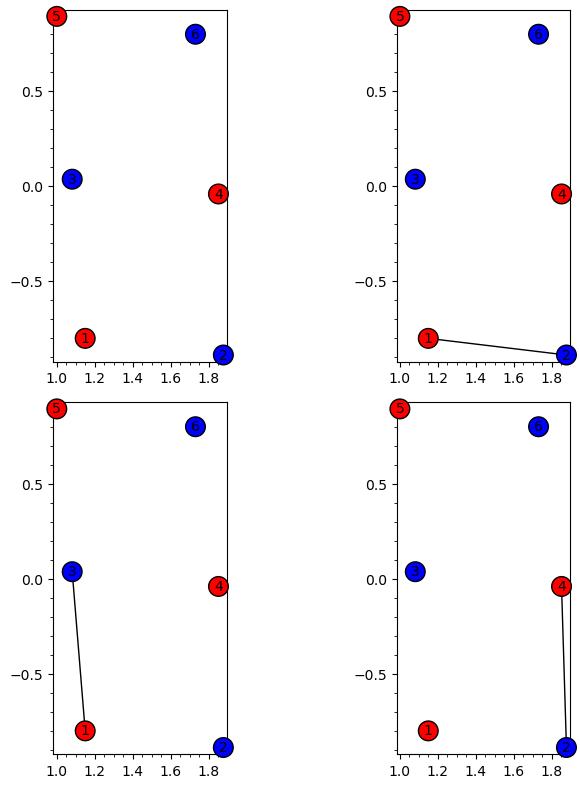

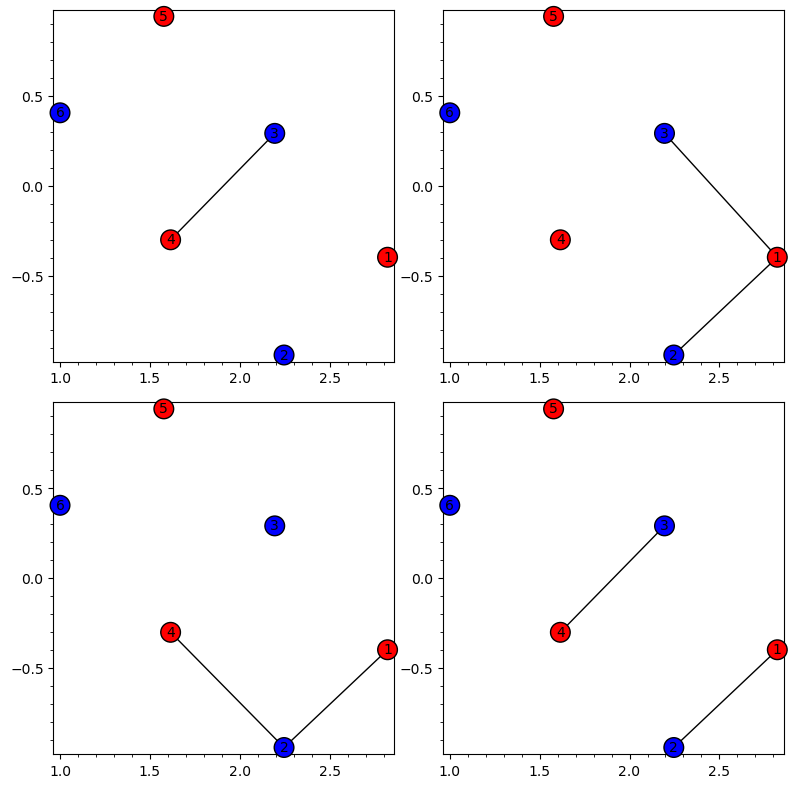

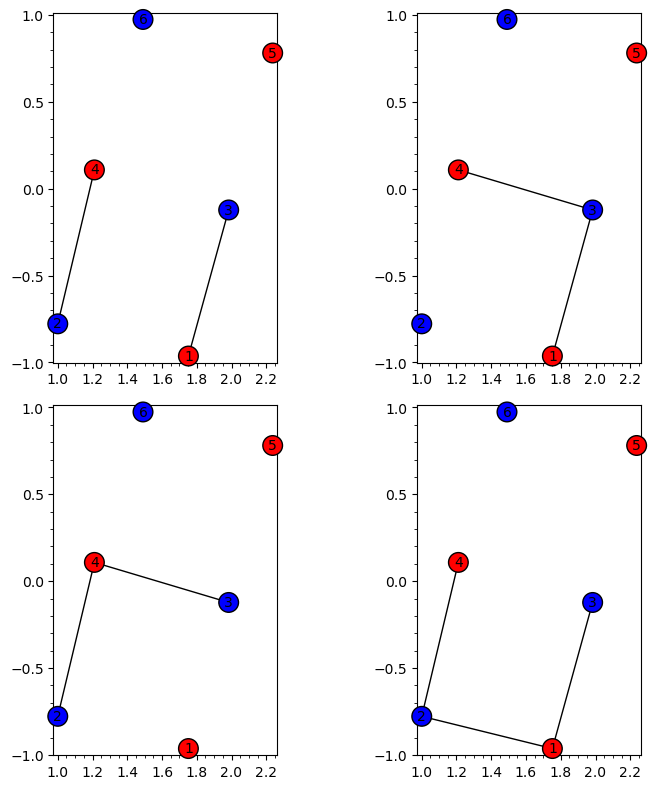

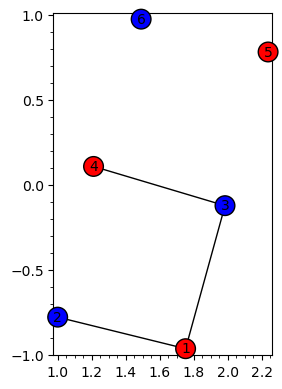

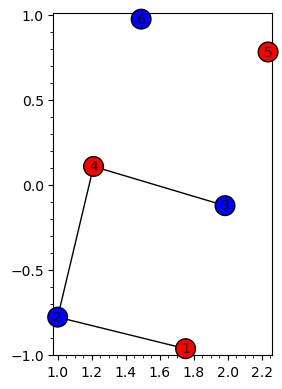

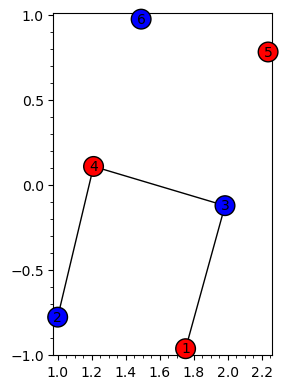

In [ ]:
for i in range(3):
    p1, p2, p3, p4 = domain_4[4 * i: 4 * i + 4]

    pos = G.layout()

    plots = graphics_array([
        [p1.plot(vertex_colors=color_dict, pos=pos, frame=True),
         p2.plot(vertex_colors=color_dict, pos=pos, frame=True)],
        [p3.plot(vertex_colors=color_dict, pos=pos, frame=True),
         p4.plot(vertex_colors=color_dict, pos=pos, frame=True)]
        ])

    plots.show(figsize=[8, 8])

domain_4[12].show(vertex_colors=color_dict, pos=pos, frame=True)
domain_4[13].show(vertex_colors=color_dict, pos=pos, frame=True)
domain_4[14].show(vertex_colors=color_dict, pos=pos, frame=True)

Visualizing the codomain (same as handwritten)

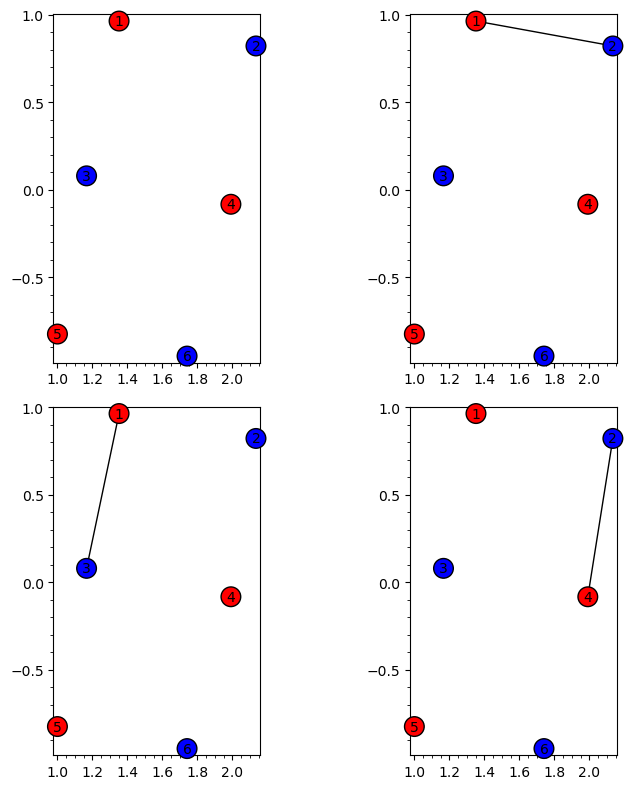

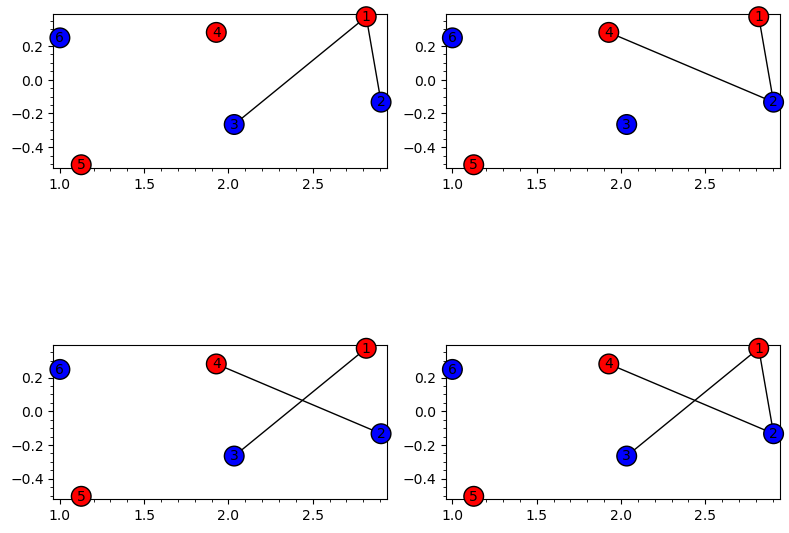

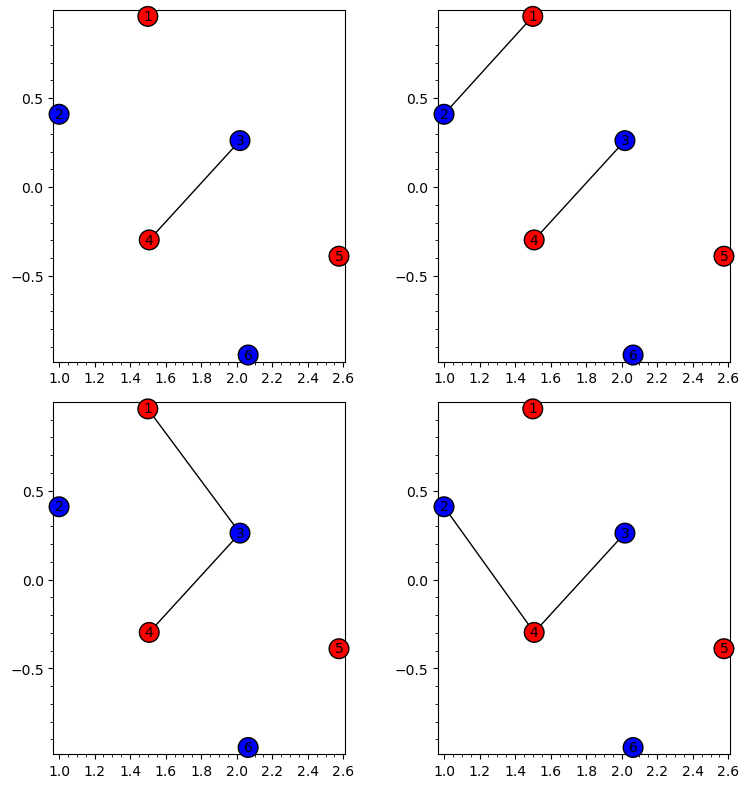

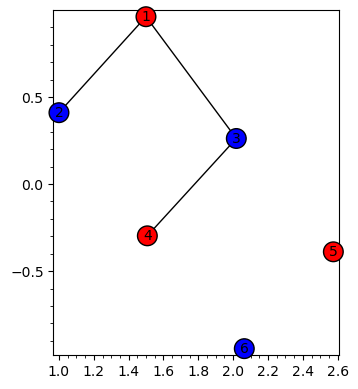

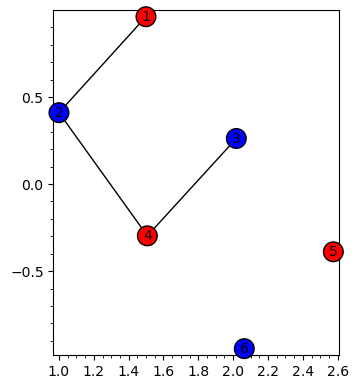

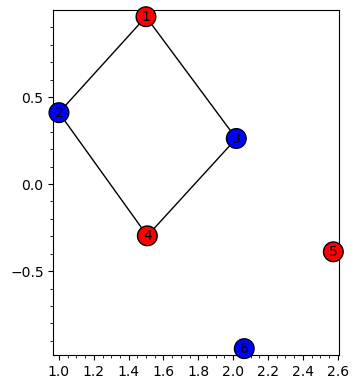

In [ ]:
for i in range(3):
    p1, p2, p3, p4 = codomain_4[4 * i: 4 * i + 4]

    pos = G.layout()

    plots = graphics_array([
        [p1.plot(vertex_colors=color_dict, pos=pos, frame=True),
         p2.plot(vertex_colors=color_dict, pos=pos, frame=True)],
        [p3.plot(vertex_colors=color_dict, pos=pos, frame=True),
         p4.plot(vertex_colors=color_dict, pos=pos, frame=True)]
        ])

    plots.show(figsize=[8, 8])

codomain_4[12].show(vertex_colors=color_dict, pos=pos, frame=True)
codomain_4[13].show(vertex_colors=color_dict, pos=pos, frame=True)
codomain_4[14].show(vertex_colors=color_dict, pos=pos, frame=True)

Testing bijection on G5 (already flawed as code utilizes the codomain for G4)

In [ ]:
# Testing for G5

# Generate list of subgraphs
subs_5 = all_subgraphs(G5)
# Generate list of subgraphs with alternating cycles
alt_cycs_5 = find_alt_cycles(G5)
# Generate cycles as lists of edges (tuples)
cycles_5 = make_cycles(G5)

# Identify new edge between G4 and G5
new_edge = (4, 6)

# Create domain for G5 (all subforests of G5)
domain_5 = []

for sub in subs_5:
    if sub.is_forest():
        domain_5.append(sub)

# Create codomain for G5 (copy of codomain of G4 to be added to)
codomain_5 = codomain_4.copy()

# Identify subforests including new edge
new_maps = []

for s in domain_5:
    if s not in domain_4:
        new_maps.append(s)

# Add mapping to codomain based on theory of bijection
for h in new_maps:
    h_prime = h.copy()
    # Delete new edge from h
    h_prime.delete_edge(new_edge)
    # Test if h contains an alternating cycle
    if h_prime in alt_cycs_5:
        # If yes, find for which cycle it alternates, and complete cycle
        e = {tuple(sorted(edge)) for edge in h_prime.edges(labels=False)}
        for cyc in cycles_5:
            c = [tuple(sorted(edge)) for edge in cyc]
            c1 = c[::2]
            c2 = c[1::2]
            if ((all(edge in e for edge in c1)) and (all(edge not in e for edge in c2))) or ((all(edge in e for edge in c2)) and (all(edge not in e for edge in c1))):
                h_prime.add_edges(c)
        codomain_5.append(h_prime)
    else:
        # If no, map to itself (before deleting new edge)
        codomain_5.append(h)

print("The number of subforests (domain): {}".format(len(domain_5)))
print("The size of the codomain mapping forests to subgraphs using bijection: {}".format(len(codomain_5)))

ds_5 = set()

for graph in codomain_5:
    ds_5.add(tuple(get_sequence(graph)))

print("The number of distinct degree sequences of subgraphs in the codomain: {}".format(len(ds_5)))

The number of subforests (domain): 30
The size of the codomain mapping forests to subgraphs using bijection: 30
The number of distinct degree sequences of subgraphs in the codomain: 27


In [13]:
def graph_to_indicator_tuple(G, vertices=None):
    """
    If `vertices` is provided, the tuple is indexed over that fixed vertex set
    rather than G's own vertices. This lets subgraph tuples stay position-
    compatible with the parent graph's tuple.

    Example:
        sage: G = Graph([(0,1), (1,2), (2,3)])
        sage: H = G.subgraph(vertices=[0,1,2])
        sage: all_verts = G.vertices()
        sage: graph_to_indicator_tuple(G, vertices=all_verts)
        (1, 0, 0, 1, 0, 1)
        sage: graph_to_indicator_tuple(H, vertices=all_verts)
        (1, 0, 0, 1, 0, 0)  # same length, same positions, (2,3) now 0
    """
    vertices = sorted(vertices if vertices is not None else G.vertices())
    edge_set = set(
        (min(u, v), max(u, v)) for u, v in G.edges(labels=False)
    )

    indicator = tuple(
        1 if (u, v) in edge_set else 0
        for i, u in enumerate(vertices)
        for v in vertices[i + 1:]
    )

    return indicator

def indicator_tuple_to_graph(indicator, vertices):
    """
    Convert a flat indicator tuple back into a SageMath undirected Graph.

    Parameters:
        indicator (tuple): A flat tuple of 0s and 1s, as produced by
                           graph_to_indicator_tuple.
        vertices (list):   The ordered list of vertices used when the
                           indicator tuple was created.

    Returns:
        sage.graphs.graph.Graph: The reconstructed undirected Graph.

    Example:
        sage: indicator_tuple_to_graph((1, 0, 0, 1, 0, 1), [0, 1, 2, 3])
        Graph on 4 vertices and 3 edges
    """
    vertices = sorted(vertices)
    pairs = [
        (u, v)
        for i, u in enumerate(vertices)
        for v in vertices[i + 1:]
    ]

    edges = [pair for pair, val in zip(pairs, indicator) if val == 1]

    G = Graph()
    G.add_vertices(vertices)
    G.add_edges(edges)

    return G

=== G ===
Graph on 4 vertices


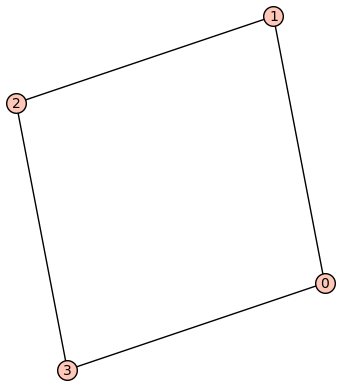


=== H (subgraph) ===
Subgraph of ()


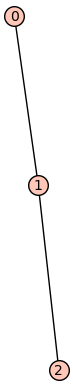


G edges: [(0, 1), (0, 3), (1, 2), (2, 3)]
H edges: [(0, 1), (1, 2)]

G tuple: (1, 0, 1, 1, 0, 1)
H tuple: (1, 0, 0, 1, 0, 0)



In [15]:
G = Graph([(0,1), (1,2), (2,3), (0,3)])
H = G.subgraph(vertices=[0,1,2])
all_verts = G.vertices()

g_tuple = graph_to_indicator_tuple(G, vertices=all_verts)
h_tuple = graph_to_indicator_tuple(H, vertices=all_verts)

print("=== G ===")
print(G)
G.show()

print("\n=== H (subgraph) ===")
print(H)
H.show()

print("\nG edges:", G.edges(labels=False))
print("H edges:", H.edges(labels=False))
print()
print("G tuple:", g_tuple)
print("H tuple:", h_tuple)
print()

Indicator: (1, 0, 0, 1, 0, 1)
Reconstructed: Graph on 4 vertices


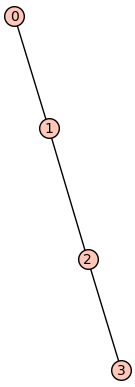

In [14]:
# Round-trip test
G = Graph([(0,1), (1,2), (2,3)])
all_verts = G.vertices()

indicator = graph_to_indicator_tuple(G, vertices=all_verts)
print("Indicator:", indicator)        # (1, 0, 0, 1, 0, 1)

G_reconstructed = indicator_tuple_to_graph(indicator, all_verts)
print("Reconstructed:", G_reconstructed)
G_reconstructed.show()